<a href="https://colab.research.google.com/github/Michel1412/Aulas_de_IA/blob/main/Trabalho_michas_Regras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd

# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv"

# Carregar dados
df = pd.read_csv(url)

# Mapeamento para nomes simples e sem espaços
mapping = {
    "Carimbo de data/hora": "timestamp",
    "Você ficou gripado no ano passado ?": "gripe_ano_passado",
    "Você tomou vacina da gripe no ano passado?": "vacina",
    "  Você frequentou no ano passado,  semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)  ": "ambientes_cheios",
    "  Você viajou no ano passado mais de 100 km de distância?  ": "viajou",
    "  Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?  ": "alergia",
    "Quantas horas você dormiu em média por noite no ano passado?": "horas_sono",
    "Você praticou atividade física no ano passado?": "exercicio",
    "Você se alimentou de forma balanceada no ano passado?": "alimentacao",
    "Em média, quantas vezes você lavou as mãos por dia no ano passado?": "lavagem_maos",
    "Na sua percepção, o seu nível de estresse no ano passado foi:": "estresse"
}

# Renomear e limpar
df_cleaned = df.rename(columns=mapping).dropna()

print("Dados carregados e colunas renomeadas:")
display(df_cleaned.head())

Dados carregados e colunas renomeadas:


,timestamp,gripe_ano_passado,vacina,ambientes_cheios,viajou,alergia,horas_sono,exercicio,alimentacao,lavagem_maos,estresse
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Make a copy to avoid modifying the original cleaned DataFrame
df_processed = df_cleaned.copy()

# 1. Encoding Binary Categorical Variables ('Sim'/'Não')
# These columns need to be converted to numerical (0 or 1)
binary_cols = [
    'gripe_ano_passado',
    'vacina',
    'ambientes_cheios',
    'exercicio',
    'alimentacao',
    'viajou',
    'alergia'
]

for col in binary_cols:
    # Strip whitespace, then map, then fill NaNs and convert to int
    df_processed[col] = df_processed[col].astype(str).str.strip().map({'Sim': 1, 'Não': 0})
    # Fill remaining NaNs (if any, e.g. from original data or unmapped strings), assuming 'No' (0)
    df_processed[col] = df_processed[col].fillna(0).astype(int)

# 2. Encoding Ordinal Categorical Variable 'estresse'
stress_mapping = {
    "Muito baixo": 0,
    "Baixo": 1,
    "Médio": 2,
    "Alto": 3,
    "Muito alto": 4
}
# Strip whitespace, then map
df_processed['estresse'] = df_processed['estresse'].astype(str).str.strip().map(stress_mapping)
# Calculate median, handle if it's NaN (meaning all values were unmappable/NaN)
median_estresse = df_processed['estresse'].median()
fill_value_estresse = median_estresse if not pd.isna(median_estresse) else 2 # Default to 'Médio' (2)
df_processed['estresse'] = df_processed['estresse'].fillna(fill_value_estresse).astype(int)

# 3. Encoding Ordinal Categorical Variable 'horas_sono'
sleep_hours_mapping = {
    "4 horas ou menos": 0,
    "entre 4 e 6 horas": 1,
    "mais de 6 horas": 2
}
# Strip whitespace, then map
df_processed['horas_sono'] = df_processed['horas_sono'].astype(str).str.strip().map(sleep_hours_mapping)
# Calculate median, handle if it's NaN
median_horas_sono = df_processed['horas_sono'].median()
fill_value_horas_sono = median_horas_sono if not pd.isna(median_horas_sono) else 1 # Default to 'entre 4 e 6 horas' (1)
df_processed['horas_sono'] = df_processed['horas_sono'].fillna(fill_value_horas_sono).astype(int)

# 4. Encoding Ordinal Categorical Variable 'lavagem_maos'
hand_washing_mapping = {
    "2 vezes ou menos": 0,
    "3 a 5 vezes": 1,
    "6 a 10 vezes": 2,
    "Mais de 10 vezes": 3
}
# Strip whitespace, then map
df_processed['lavagem_maos'] = df_processed['lavagem_maos'].astype(str).str.strip().map(hand_washing_mapping)
# Calculate median, handle if it's NaN
median_lavagem_maos = df_processed['lavagem_maos'].median()
fill_value_lavagem_maos = median_lavagem_maos if not pd.isna(median_lavagem_maos) else 1 # Default to '3 a 5 vezes' (1)
df_processed['lavagem_maos'] = df_processed['lavagem_maos'].fillna(fill_value_lavagem_maos).astype(int)

# 5. Handle 'timestamp' column (optional: drop for this model if not extracting time-based features)
# For a rule-based model, raw timestamp might not be directly useful. Let's drop it for now.
df_processed = df_processed.drop('timestamp', axis=1)

# Display processed data head
print("Dados após codificação de variáveis e tratamento de NaNs:")
display(df_processed.head())

# Add checks for NaNs and dtypes before SMOTE
print("\nVerificando NaNs e dtypes antes do SMOTE:")
print(df_processed.isnull().sum())
print(df_processed.dtypes)

# 6. Balancing the dataset for the target variable 'gripe_ano_passado'

# Define the target variable
y = df_processed['gripe_ano_passado']

# --- MODIFICAÇÃO: Seleção de Features para Treinamento ---
# Você pode ajustar esta lista para incluir/excluir as features que deseja usar no modelo.
# Certifique-se de não incluir 'gripe_ano_passado' na lista de features.
selected_features = [
    'vacina',
    'ambientes_cheios',
    'viajou',
    'alergia',
    'horas_sono',
    'exercicio',
    'alimentacao',
    'lavagem_maos',
    'estresse'
]

X = df_processed[selected_features]  # Features selecionadas

print(f"\nDistribuição da variável alvo antes do balanceamento:\n{y.value_counts()}")

# Check for imbalance and apply SMOTE if needed
# Assuming imbalance if one class is significantly smaller (e.g., less than 80% of the other)
if y.value_counts().min() / y.value_counts().max() < 0.8:
    print("Aplicando SMOTE para balancear a base de dados...")
    smote = SMOTE(random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X, y)
    print(f"Distribuição da variável alvo após SMOTE:\n{y_balanced.value_counts()}")
else:
    print("A variável alvo já está razoavelmente balanceada, SMOTE não aplicado.")
    X_balanced, y_balanced = X, y

print("\nBase de dados tratada e balanceada (se necessário) pronta para modelagem.")
print(f"Shape de X_balanced: {X_balanced.shape}")
print(f"Shape de y_balanced: {y_balanced.shape}")

Dados após codificação de variáveis e tratamento de NaNs:


,gripe_ano_passado,vacina,ambientes_cheios,viajou,alergia,horas_sono,exercicio,alimentacao,lavagem_maos,estresse
0,1,1,1,0,0,0,1,0,1,2
1,1,1,1,0,0,1,0,0,3,2
2,1,0,1,0,0,2,1,0,2,2
3,1,0,0,0,0,2,1,0,0,2
4,1,1,1,0,0,1,0,0,2,2



Verificando NaNs e dtypes antes do SMOTE:
gripe_ano_passado    0
vacina               0
ambientes_cheios     0
viajou               0
alergia              0
horas_sono           0
exercicio            0
alimentacao          0
lavagem_maos         0
estresse             0
dtype: int64
gripe_ano_passado    int64
vacina               int64
ambientes_cheios     int64
viajou               int64
alergia              int64
horas_sono           int64
exercicio            int64
alimentacao          int64
lavagem_maos         int64
estresse             int64
dtype: object

Distribuição da variável alvo antes do balanceamento:
gripe_ano_passado
1    108
0     77
Name: count, dtype: int64
Aplicando SMOTE para balancear a base de dados...
Distribuição da variável alvo após SMOTE:
gripe_ano_passado
1    108
0    108
Name: count, dtype: int64

Base de dados tratada e balanceada (se necessário) pronta para modelagem.
Shape de X_balanced: (216, 9)
Shape de y_balanced: (216,)


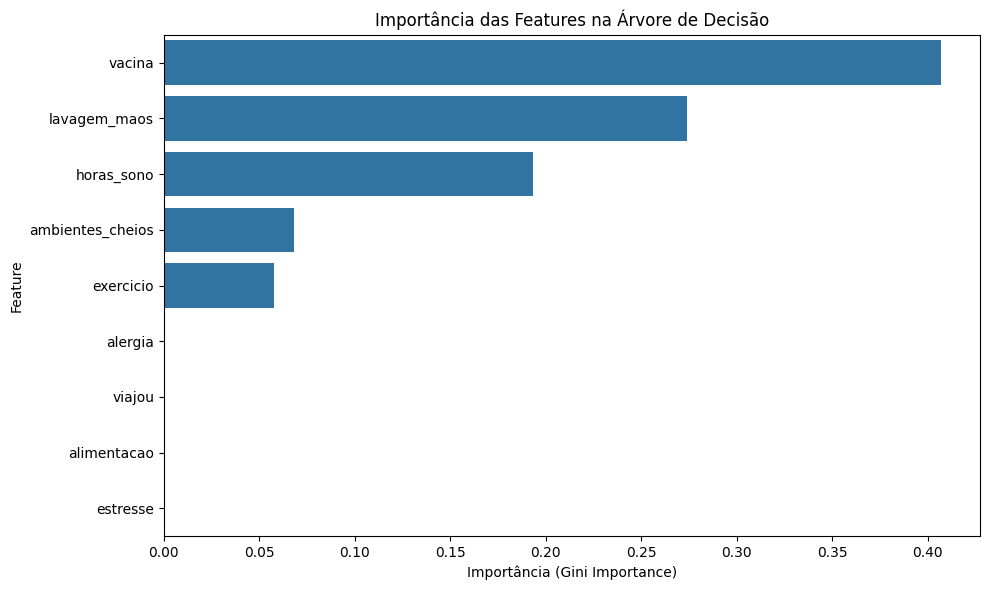

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obter a importância das features do modelo
feature_importances = dt_classifier.feature_importances_
feature_names = X_balanced.columns

# Criar um DataFrame para facilitar a visualização e ordenação
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar as features por importância em ordem decrescente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features na Árvore de Decisão')
plt.xlabel('Importância (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Acurácia do Modelo de Árvore de Decisão no conjunto de teste: 0.5682

Modelo de Árvore de Decisão treinado com sucesso. Agora gerando o gráfico de importância das features.


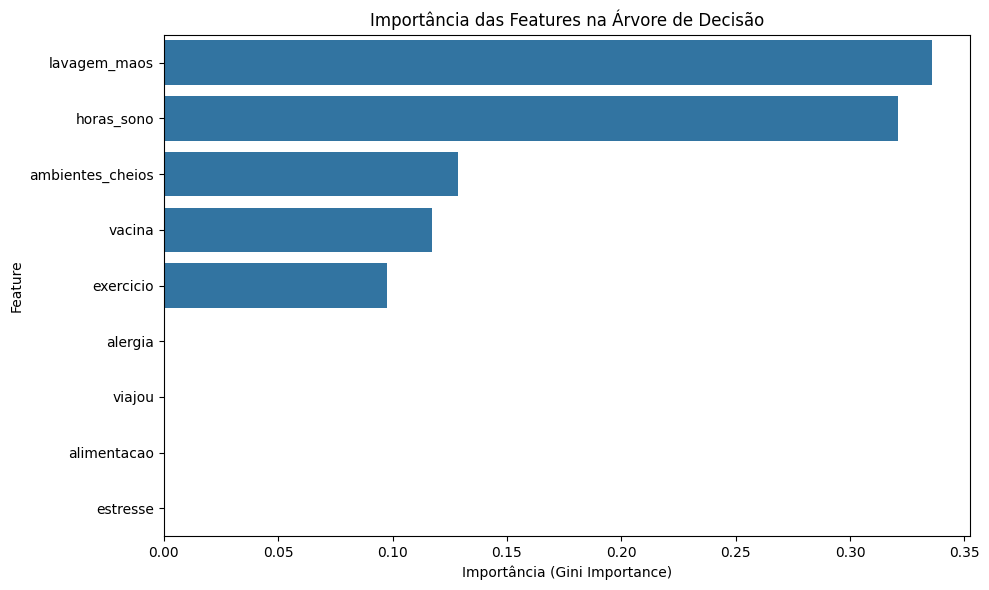

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dividir os dados balanceados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Inicializar o Classificador de Árvore de Decisão
# Usamos uma profundidade máxima para manter as regras interpretáveis
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42)

# Treinar o modelo
dt_classifier.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = dt_classifier.predict(X_test)

# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo de Árvore de Decisão no conjunto de teste: {accuracy:.4f}")

print("\nModelo de Árvore de Decisão treinado com sucesso. Agora gerando o gráfico de importância das features.")

# Obter a importância das features do modelo
feature_importances = dt_classifier.feature_importances_
feature_names = X_balanced.columns

# Criar um DataFrame para facilitar a visualização e ordenação
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Ordenar as features por importância em ordem decrescente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features na Árvore de Decisão')
plt.xlabel('Importância (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Dividir os dados balanceados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Inicializar o Classificador de Árvore de Decisão
# Usamos uma profundidade máxima para manter as regras interpretáveis
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinar o modelo
dt_classifier.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = dt_classifier.predict(X_test)

# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo de Árvore de Decisão no conjunto de teste: {accuracy:.4f}")

print("\nModelo de Árvore de Decisão treinado com sucesso. As regras serão extraídas no próximo passo.")

Acurácia do Modelo de Árvore de Decisão no conjunto de teste: 0.5455

Modelo de Árvore de Decisão treinado com sucesso. As regras serão extraídas no próximo passo.


In [83]:
from sklearn.tree import export_text

# Gerar as regras da árvore de decisão
tree_rules = export_text(dt_classifier, feature_names=X_balanced.columns.tolist())

print("Regras da Árvore de Decisão:")
print(tree_rules)

# Para apresentar em um formato mais tabular, podemos processar a string (exemplo simplificado)
# Uma abordagem mais complexa envolveria parsing a string ou usar bibliotecas como dtreeviz
# Por simplicidade, vamos apresentar a string formatada aqui.

print("\nInterpretação das Regras (Exemplo - cada linha representa uma condição para a decisão final):\n")

# Mapeamento para nomes de classes mais legíveis
class_names_map = {0: 'Não pegou gripe', 1: 'Pegou gripe'}

def format_rules(rules_text, feature_names, class_names_map):
    formatted_output = []
    for line in rules_text.split('\n'):
        if '|---' in line:
            indent = line.count('|   ')
            clean_line = line.replace('|---', '').replace('|   ', '').strip()

            if 'class:' in clean_line:
                prediction_label = int(float(clean_line.split('class: ')[1]))
                class_name = class_names_map.get(prediction_label, f'Classe {prediction_label}')
                formatted_output.append(f"{'  ' * indent}--> Previsão: {class_name}")
            elif '<=' in clean_line or '>' in clean_line:
                # Extract feature, operator, threshold, and impurity/samples if present
                parts = clean_line.split(' ', 2)
                feature = parts[0]
                operator = parts[1]
                threshold_and_rest = parts[2]

                if 'value' in threshold_and_rest:
                    threshold = threshold_and_rest.split(' ')[0]
                    rest = threshold_and_rest.split('value')[1].strip()
                else:
                    threshold = threshold_and_rest.split(' ')[0]
                    rest = ''

                formatted_output.append(f"{'  ' * indent}Se {feature} {operator} {threshold}")
    return "\n".join(formatted_output)

# Chamada da função para formatar e imprimir
formatted_rules = format_rules(tree_rules, X_balanced.columns.tolist(), class_names_map)
print(formatted_rules)

print("\nAs regras completas da árvore de decisão foram extraídas. Cada linha com 'Se' representa uma condição e cada linha com '--> Previsão' representa o resultado final se essas condições forem atendidas.")

Regras da Árvore de Decisão:
|--- ambientes_cheios <= 0.50
|   |--- vacina <= 0.50
|   |   |--- horas_sono <= 1.50
|   |   |   |--- class: 1
|   |   |--- horas_sono >  1.50
|   |   |   |--- lavagem_maos <= 1.50
|   |   |   |   |--- exercicio <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- exercicio >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- lavagem_maos >  1.50
|   |   |   |   |--- class: 1
|   |--- vacina >  0.50
|   |   |--- lavagem_maos <= 2.50
|   |   |   |--- class: 0
|   |   |--- lavagem_maos >  2.50
|   |   |   |--- horas_sono <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- horas_sono >  1.50
|   |   |   |   |--- class: 0
|--- ambientes_cheios >  0.50
|   |--- exercicio <= 0.50
|   |   |--- lavagem_maos <= 1.50
|   |   |   |--- lavagem_maos <= 0.50
|   |   |   |   |--- horas_sono <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- horas_sono >  1.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- lavagem_maos >  0.50
|   |   | 